# Qwen3.5-9B (multimodal) — MathVista failure mining

This notebook runs the multimodal **`Qwen/Qwen3.5-9B`** model on the
**MathVista** (`AI4Math/MathVista`, `testmini` split) benchmark, scores each prediction
against the ground truth, and **saves the inputs the model gets wrong** into a
`failures/` folder (image + metadata) so they can be inspected later.

The loop streams through `testmini` until it has collected `TARGET_FAILURES` (default **10**)
wrong cases, then stops — so the run stays short on a single 24 GB GPU (e.g. an RTX 4090 on
vast.ai). Lower `TARGET_FAILURES` for a faster run; raise `MAX_SAMPLES` if the model is strong
enough that 10 failures aren't found early.

**Notes**
* `Qwen/Qwen3.5-9B` is a reasoning VL model. We run it with `enable_thinking=False` so it
  answers concisely (long chain-of-thought is much slower and gets truncated). It still
  reasons briefly and ends with a clear final answer (`\boxed{...}`, `Answer: X`, or a
  trailing line), which the extractor below parses.
* The scorer is a heuristic (MathVista-style): option-letter / numeric-tolerance /
  text match. It is good enough to surface clear failures, not a leaderboard-grade scorer.

## 1. Install dependencies

The vast.ai image already ships `torch`. We add the HF stack on top. Skip this cell if already installed.

In [1]:
# Uses the venv that already has torch (/venv/main on this vast.ai image).
# On a generic Colab/Jupyter, just run: %pip install -U "transformers>=4.57" accelerate datasets qwen-vl-utils pillow matplotlib
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "transformers>=4.57", "accelerate", "datasets", "qwen-vl-utils", "pillow", "matplotlib"], check=True)
print("deps ready")

deps ready


## 2. Configuration

In [2]:
import os
# Keep the big HF cache off the small root disk on vast.ai images.
os.environ.setdefault("HF_HOME", "/workspace/.hf_home")

MODEL_ID        = "Qwen/Qwen3.5-9B"   # multimodal (image-text-to-text) reasoning model
TARGET_FAILURES = 10                   # keep evaluating until this many *clean* wrong cases are collected
MAX_SAMPLES     = 150                  # safety cap so a strong model can't loop forever
MAX_NEW         = 1536                 # generation budget; large enough that reasoning finishes
OUT_DIR         = "failures"          # where wrong-answer cases get stored
print(f"model={MODEL_ID}  target_failures={TARGET_FAILURES}  max_samples={MAX_SAMPLES}  "
      f"max_new_tokens={MAX_NEW}  HF_HOME={os.environ['HF_HOME']}")

model=Qwen/Qwen3.5-9B  target_failures=10  max_samples=150  max_new_tokens=1536  HF_HOME=/workspace/.hf_home


## 3. Load the model and processor (bf16, ~18 GB on GPU)

In [3]:
import time, torch
from transformers import AutoProcessor, AutoModelForImageTextToText

t0 = time.time()
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map="cuda",
).eval()
print(f"loaded in {time.time()-t0:.1f}s | GPU mem: {torch.cuda.memory_allocated()/1e9:.1f} GB")

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

loaded in 7.9s | GPU mem: 18.8 GB


## 4. Load a small MathVista subset

`testmini` (1000 examples) ships ground-truth answers. The inference loop streams through it
and stops as soon as `TARGET_FAILURES` wrong cases have been collected (or `MAX_SAMPLES` is hit).

Dataset({
    features: ['pid', 'question', 'image', 'decoded_image', 'choices', 'unit', 'precision', 'answer', 'question_type', 'answer_type', 'metadata', 'query'],
    num_rows: 1000
})
fields: ['pid', 'question', 'image', 'decoded_image', 'choices', 'unit', 'precision', 'answer', 'question_type', 'answer_type', 'metadata', 'query']
example question_type: free_form | answer: 1.2


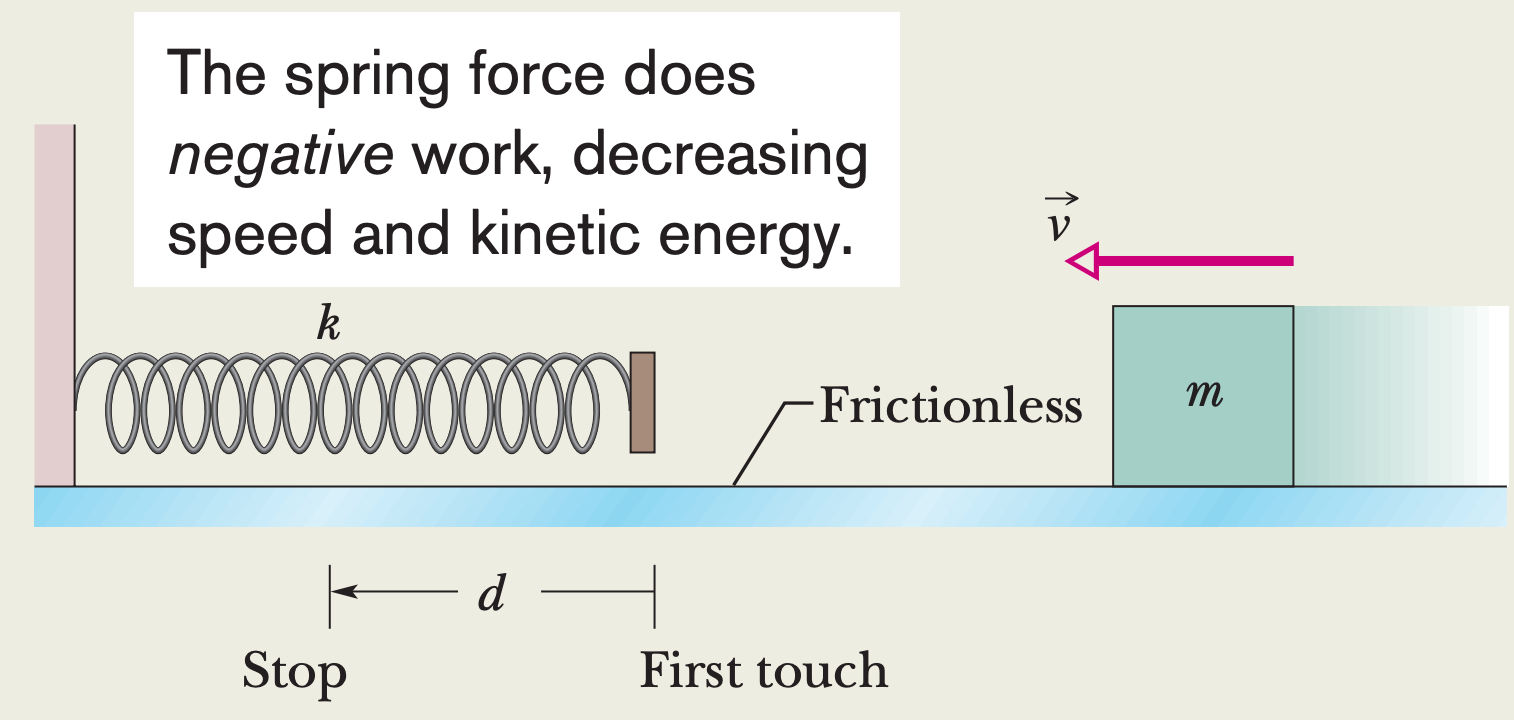

In [4]:
from datasets import load_dataset

# Load the full testmini split (1000 examples, with ground-truth answers).
# The inference loop below streams through it only until TARGET_FAILURES is reached.
ds = load_dataset("AI4Math/MathVista", split="testmini")
print(ds)
ex = ds[0]
print("fields:", list(ex.keys()))
print("example question_type:", ex["question_type"], "| answer:", ex["answer"])
ex["decoded_image"]  # renders inline

## 5. Answer extraction + scoring

MathVista answers come in three flavours: multiple-choice (compare option text),
free-form numeric (compare with a precision tolerance), and free-form text (string match).

In [5]:
import re

def last_number(s):
    m = re.findall(r"-?\d+(?:\.\d+)?", str(s).replace(",", ""))
    return float(m[-1]) if m else None

def extract_pred(resp, ex):
    """Pull the model's final answer out of its free-form reasoning text."""
    tail = resp.strip()
    boxed = re.findall(r"\\boxed\{([^{}]*)\}", tail)
    boxed = boxed[-1].strip() if boxed else None
    window = tail[-200:]  # the final answer lives near the end

    if ex["question_type"] == "multi_choice":
        choices = ex["choices"]
        letters = {chr(65 + i): c for i, c in enumerate(choices)}
        if boxed and boxed.upper() in letters:                 # \boxed{C}
            return letters[boxed.upper()]
        if boxed:                                              # \boxed{145°}
            for c in choices:
                if str(c).strip().lower() == boxed.lower():
                    return c
        for L in reversed(re.findall(r"\b([A-D])\b", window)):  # trailing '(C)'
            if L in letters:
                return letters[L]
        hit = None                                             # choice text mentioned
        for c in choices:
            if str(c).strip().lower() in tail.lower():
                hit = c
        return hit if hit is not None else window[-40:]

    if ex["answer_type"] in ("integer", "float"):
        if boxed and last_number(boxed) is not None:
            return last_number(boxed)
        return last_number(window)

    if boxed:
        return boxed
    return window.splitlines()[-1].strip() if window.strip() else ""

def is_correct(pred, ex):
    gt = ex["answer"]
    if ex["question_type"] == "multi_choice":
        return str(pred).strip().lower() == str(gt).strip().lower()
    if ex["answer_type"] in ("integer", "float"):
        p = pred if isinstance(pred, float) else last_number(pred)
        g = last_number(gt)
        if p is None or g is None:
            return False
        if ex["answer_type"] == "integer":
            return abs(p - g) <= 0.5
        prec = int(ex.get("precision") or 1)
        return abs(p - g) <= 0.5 * 10 ** (-prec) + 1e-9
    return str(pred).strip().lower() == str(gt).strip().lower()

## 6. Run inference over the subset

In [6]:
records, failures = [], []
n_truncated = 0
t_inf = time.time()
for i, ex in enumerate(ds):
    if len(failures) >= TARGET_FAILURES or i >= MAX_SAMPLES:
        break
    img = ex["decoded_image"].convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": ex["query"]},   # 'query' = question + answer-format hint
    ]}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt", enable_thinking=False,
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW, do_sample=False)
    gen = out[0][inputs["input_ids"].shape[1]:]
    finished = gen.shape[0] < MAX_NEW
    resp = processor.decode(gen, skip_special_tokens=True).strip()

    pred = extract_pred(resp, ex)
    ok = bool(is_correct(pred, ex))
    rec = dict(pid=ex["pid"], question=ex["question"], qtype=ex["question_type"],
               answer_type=ex["answer_type"], choices=ex["choices"],
               category=ex["metadata"].get("category"),
               ground_truth=str(ex["answer"]), prediction=str(pred),
               correct=ok, finished=finished, response=resp)
    records.append(rec)

    # Only COMPLETED + wrong answers count as genuine failures.
    # A truncated generation never emitted a final answer, so its 'wrong'
    # prediction is an extraction artifact, not a real model error -> skip it.
    if not finished:
        n_truncated += 1
        status = "trunc(skip)"
    elif ok:
        status = "OK"
    else:
        failures.append(rec)
        status = "XX(fail)"
    print(f"[{i+1:3}] pid={ex['pid']:>4} {status:<11} "
          f"gt={str(ex['answer'])[:18]!r} pred={str(pred)[:18]!r}   "
          f"(failures: {len(failures)})")

n = len(records); ncorrect = sum(r["correct"] for r in records)
print(f"\nScanned {n} samples in {time.time()-t_inf:.0f}s | "
      f"finished-accuracy: {ncorrect}/{n} = {ncorrect/n:.1%} | "
      f"truncated(skipped): {n_truncated} | clean failures: {len(failures)}")
if len(failures) < TARGET_FAILURES:
    print(f"WARNING: only {len(failures)} clean failures within MAX_SAMPLES={MAX_SAMPLES}; raise the cap.")

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[  1] pid=   1 trunc(skip) gt='1.2' pred='0.0'   (failures: 0)


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[  2] pid=   2 OK          gt='1000' pred='1000.0'   (failures: 0)


...

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[ 58] pid=  58 OK          gt='yes' pred='yes'   (failures: 9)


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[ 59] pid=  59 OK          gt='64°' pred='64°'   (failures: 9)


[ 60] pid=  60 XX(fail)    gt='22' pred='0.0'   (failures: 10)

Scanned 60 samples in 1162s | finished-accuracy: 44/60 = 73.3% | truncated(skipped): 7 | clean failures: 10


## 7. Save the failing inputs to `failures/`

One sub-folder per wrong example: the input `image.png` plus an `info.json` with the
question, ground truth, the model's prediction and full response. Plus a top-level `summary.json`.

In [7]:
import json, shutil
shutil.rmtree(OUT_DIR, ignore_errors=True)
os.makedirs(OUT_DIR, exist_ok=True)

for r in failures:
    fdir = os.path.join(OUT_DIR, f"pid_{r['pid']}")
    os.makedirs(fdir, exist_ok=True)
    ex = next(e for e in ds if e["pid"] == r["pid"])
    ex["decoded_image"].convert("RGB").save(os.path.join(fdir, "image.png"))
    with open(os.path.join(fdir, "info.json"), "w") as f:
        json.dump(r, f, indent=2, ensure_ascii=False)

with open(os.path.join(OUT_DIR, "summary.json"), "w") as f:
    json.dump(dict(model=MODEL_ID, n_samples=n, finished_accuracy=ncorrect / n,
                   n_truncated_skipped=n_truncated, n_failures=len(failures),
                   failure_pids=[r["pid"] for r in failures]), f, indent=2)

print(f"Saved {len(failures)} clean failing cases under ./{OUT_DIR}/")
for r in failures:
    print(f"  pid_{r['pid']}: gt={r['ground_truth']!r} pred={r['prediction']!r} ({r['category']})")

Saved 10 clean failing cases under ./failures/
  pid_7: gt='quarter' pred='quarter past' (math-targeted-vqa)
  pid_19: gt='400' pred='600.0' (general-vqa)
  pid_20: gt='No' pred='Yes' (general-vqa)
  pid_27: gt='11' pred='23.0' (general-vqa)
  pid_37: gt='3' pred='2.0' (math-targeted-vqa)
  pid_41: gt='7' pred='13.0' (general-vqa)
  pid_42: gt='8' pred='0.0' (general-vqa)
  pid_50: gt='The population of predatory insects would decrease.' pred='The population of predatory insects would increase.' (general-vqa)
  pid_53: gt='1' pred='8.0' (general-vqa)
  pid_60: gt='22' pred='0.0' (general-vqa)


## 8. Inspect the failures inline

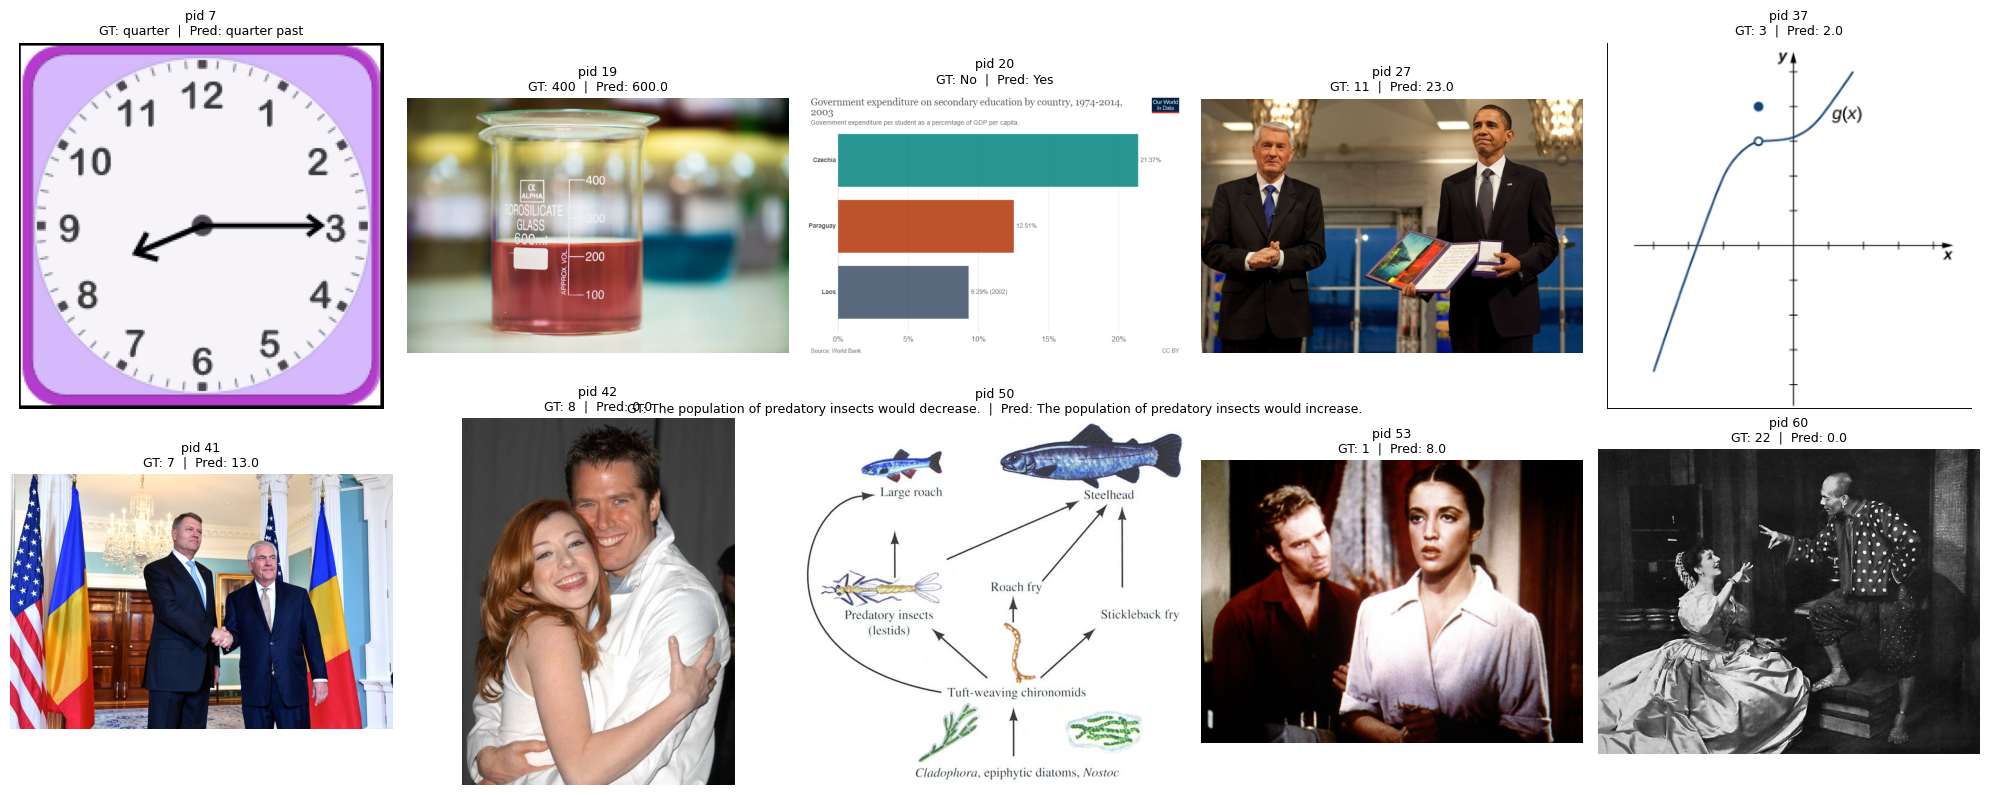


=== pid 7 (multi_choice/text) ===
Q: What time is shown? Answer by typing a time word, not a number. It is (_) after eight.
GT: quarter | Pred: quarter past
Model response (tail): The clock shows the hour hand just past 8 and the minute hand pointing at 3, which is 15 minutes past the hour. So, it is **quarter past** eight.

Correct answer: **(E) quarter past**

E

=== pid 19 (free_form/integer) ===
Q: what is the highest amount this class measures?
GT: 400 | Pred: 600.0
Model response (tail): e question asks for the **highest amount this class measures** — meaning the maximum volume it can hold or measure.

Even though the visible scale only goes to 400, the beaker is designed to hold up to 600ml (as stated on the label). So the highest amount it measures is **600**.

Final Answer:  
600

=== pid 20 (multi_choice/text) ===
Q: Is the sum of smallest two bar is greater then the largest bar?
GT: No | Pred: Yes
Model response (tail): he value given)

The **smallest two bars** are:
- Laos

In [8]:
import math
import matplotlib.pyplot as plt
from PIL import Image

if failures:
    k = len(failures)
    ncols = min(5, k)
    nrows = math.ceil(k / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = [axes] if k == 1 else list(axes.flat)
    for ax in axes[k:]:
        ax.axis("off")
    for ax, r in zip(axes, failures):
        img = Image.open(os.path.join(OUT_DIR, f"pid_{r['pid']}", "image.png"))
        ax.imshow(img); ax.axis("off")
        ax.set_title(f"pid {r['pid']}\nGT: {r['ground_truth']}  |  Pred: {r['prediction']}",
                     fontsize=9)
    plt.tight_layout(); plt.show()
    for r in failures:
        print(f"\n=== pid {r['pid']} ({r['qtype']}/{r['answer_type']}) ===")
        print("Q:", r["question"])
        print("GT:", r["ground_truth"], "| Pred:", r["prediction"])
        print("Model response (tail):", r["response"][-300:])
else:
    print("No failures found — raise MAX_SAMPLES.")